# 🏥 Preprocessing Notebook 2 — Clinical Dataset (918 unique instances, deduplicated from 1190 raw rows)
**Project:** Genetic Risk Integration with Lifestyle & Clinical Data for Cardiovascular Disease Stratification  
**Dataset:** Heart Disease — Combined UCI Sources (IEEE DataPort)  
**Output:** `df_clinical_train.csv`, `df_clinical_test.csv`, `df_clinical_test_raw.csv`, `df_clinical_train_raw.csv`, `clinical_scaler.pkl`, `clinical_imputer.pkl`, `clinical_iqr_bounds.pkl` (added 03/08/26), and a reusable `cv_safe_preprocessor` Pipeline object (Section 11b, in-notebook only, not pickled)

---

## 📌 What this notebook does (in order)
1. Loads raw data and creates a working copy (raw file is never modified)
1a. Deduplicates exact full-row duplicates (Section 2a, added 2026-07-25) — 1190 → 918 unique patients, before anything else touches the data
2. Audits the dataset — documents all issues before touching anything
3. Renames columns to human-readable snake_case names
4. Replaces sentinel zeros with NaN (missing value representation)
5. Splits into train/test (80/20, stratified) — **before fitting anything**
6. Saves raw test data immediately after split — **before imputation or scaling**
6a. Saves raw train data too, `df_clinical_train_raw.csv` (Section 7a, added 2026-07-22) — same idea, for NB6's CV-safe refactor
7. Applies IQR clipping — **using X_train-derived bounds only** (applied to both splits)
8. Applies MICE imputation — **fit on X_train only**, transform applied to both
9. One-hot encodes multi-class categorical columns
10. Applies StandardScaler — **fit on X_train only**
11. Saves clean train/test CSVs, the fitted imputer, and the fitted scaler
11a. Builds a fold-safe CV preprocessing pipeline for NB6 to reuse (Section 11b, added 2026-07-22)
12. Final validation — shape, NaN, class balance, dtype, feature integrity checks, now also covering the two additions above

---

## 📖 About this dataset

This file combines **5 UCI heart disease sources** into 1190 raw rows — **918 of these are unique patients** (see ⚠️ below):

| Source | Instances |
|---|---|
| Cleveland Clinic | 303 |
| Hungarian Institute of Cardiology | 294 |
| University Hospital Zürich (Switzerland) | 123 |
| VA Medical Center, Long Beach | 200 |
| StatLog (Heart) Dataset | 270 |
| **Total** | **1190** |

**Important:** The `ca` (major vessels) and `thal` (thalassemia) columns from the original UCI files were **intentionally omitted** at source — they had >90% missingness in several contributing datasets.  

**Do NOT merge your separate Cleveland/Hungarian files with this** — 573 Cleveland rows and 95 Hungarian rows are already present here. Using both would cause severe data duplication.

**⚠️ Known data-quality issue (found 2026-07-25):** the raw file itself already contains 272 exact full-row duplicates (verified directly: `.duplicated().sum() == 272` on the raw CSV). Left unremoved, `train_test_split` places some duplicate patients on both sides of the split — under the original (pre-fix) 80/20 split, 84 of 238 test rows (35.3%) were byte-identical to rows already in the training set. That means the "held-out" test set had already been seen by the model during training for over a third of its rows, inflating Test_AUC across every model in NB6. Section 2a removes these duplicates immediately after load, before Section 3's audit or the split — every row count from that point on in this notebook reflects the true 918 unique patients.

---

## ⚠️ Critical notes before you run
- Always run cells **top-to-bottom** — MICE imputer and scaler must be fit before transform
- MICE is fit on **X_train only** — applying to X_test uses the same fitted imputer (no refit)
- IQR bounds are computed on **X_train only** and applied to X_test — no leakage
- Missing values in this dataset are encoded as **0** (not NaN) — we convert them in Section 5
- `df_clinical_test_raw.csv` has **12 columns** (pre-encoding); processed outputs have **19 columns** after one-hot encoding — this is expected and correct
- `df_clinical_train_raw.csv` (added 2026-07-22) mirrors `df_clinical_test_raw.csv`: same 12 columns, pre-clip/impute/scale — used only by NB6's CV-safe pipeline, not by the deployment artifacts above
- Raw file has 272 exact duplicate rows (verified) — removed in **Section 2a** before anything else runs; all downstream counts (audit, split, exports) reflect **918 unique patients**, not 1190

---

## ⚠️ Found 03/08/26 while building the single-patient wrapper (Section 14)
**`iqr_bounds` (Section 7b) was computed in-memory but never saved to disk** — unlike `clinical_imputer.pkl` and `clinical_scaler.pkl`, which both do get pickled. This meant there was no way to replicate Section 7b's clipping step for a new patient at inference time. Fixed: now saved as `clinical_iqr_bounds.pkl`.

**Separate architectural note, not fixed here:** `df_clinical_train.csv`/`df_clinical_test.csv` are saved **already Z-scored** by this notebook's own Section 10 (`clinical_scaler.pkl`). NB6's `clinical_pipeline` then wraps `Pipeline([StandardScaler, clf])` and fits **its own second StandardScaler** on that already-scaled data when building the final model. This is the same double-scaling issue class NB1 had already caught and fixed for the lifestyle pipeline (scaling deferred entirely to NB5) — NB2/NB6 never got the equivalent fix. Numerically it's close to a no-op here (re-scaling already ≈N(0,1) data changes very little), so it's very unlikely to have measurably affected any reported AUC/Brier numbers — but it's worth knowing about, and it directly shapes how `build_clinical_features()` (Section 14) must be written: it has to reproduce **both** scaling steps in the same order training data went through them, not just one. Flagging this now rather than silently working around it — whether to actually fix the architecture (make NB2 stop scaling, matching NB1's fix) is a call for you to make, not something I'm changing without being asked.


> **Edit log — 2026-07-22:** comments wherever necessary things have been changed, mentioning what's changed:
> - Section 5: added the missing sentence on why `oldpeak=0` is excluded from sentinel-zero replacement (checklist item, not previously written).
> - Section 7: added a raw (unclipped/unimputed/unscaled) train export, `df_clinical_train_raw.csv` — pure addition, nothing existing changes shape.
> - New Section 11b: added `IQRClipper` + `cv_safe_preprocessor` Pipeline, for NB6 to fit fresh inside each CV split instead of reading the already-transformed train CSV. One correction made to the originally sketched pipeline: a bare `StandardScaler()` on the whole frame would have also scaled the categorical columns (sex, chest_pain_type, resting_ecg, exercise_angina, fasting_blood_sugar, st_slope), which Section 10 does NOT do — it only scales `SCALE_COLS`. Fixed by wrapping the scaler in a `ColumnTransformer` with `remainder='passthrough'` so untouched columns stay untouched, matching Section 10's behavior exactly. Also added rounding of `cholesterol`/`resting_bp`/`st_slope` after MICE, mirroring Section 8's post-imputation rounding.
> - Nothing in Sections 7b/8/10/11's existing code was changed — the final `clinical_scaler.pkl` / `clinical_imputer.pkl` / `df_clinical_train.csv` outputs are untouched.

> **Follow-up — 2026-07-22 (same day, reviewer pass):** three gaps found and fixed:
> - Header docstring (`**Output:**` line and step list) updated to mention `df_clinical_train_raw.csv` and the Section 11b pipeline — it was stale after the first edit pass.
> - "Critical notes before you run" bullet list updated to mention `df_clinical_train_raw.csv`.
> - Section 13's Final Pipeline Validation now has two new checks: [8] raw train export shape, and [9] CV-safe pipeline fences vs. Section 7b — both are hard `assert`s now, not just prints, so a future silent regression fails the notebook instead of passing quietly.
> - Section 11b's own sanity check upgraded from a print to an `assert` (`np.isclose` against Section 7b's actual `iqr_bounds`), for the same reason.

> **Edit log — 2026-07-25:** duplicate-row test-set leakage found and fixed:
> - New **Section 2a**: drops exact full-row duplicates immediately after load (272 found, 1190 → 918 unique patients) — runs *before* Section 3's audit, so every printed count from that point on reflects the real dataset, not the un-deduplicated one. Root cause: the merged source file embeds overlapping records across its five contributing sources (this is a known issue with this specific IEEE DataPort file, not something introduced by this pipeline).
> - Verified impact of *not* having this fix: under the original 80/20 split (no dedup), 84 of 238 test rows (35.3%) were exact duplicates of rows in the training set — meaning roughly a third of the "held-out" test set had already been seen during training. This inflated `Test_AUC` for every model in NB6, not only the ones flagged as overfit.
> - Section 13: added check **[10]**, a hard assert that zero rows are byte-identical across the train/test raw exports. This is a permanent regression guard, not a one-time patch — if a future edit reintroduces the leak, the notebook fails loudly instead of silently producing inflated metrics again.
> - Section 12 (EDA plots): every subplot was missing axis labels, and two titles said "(scaled)" without saying what that means on the axis. All 6 subplots now have explicit x/y axis labels stating units (z-score vs. raw patient count) and which split (train) the plot is drawn from.
> - Header (`About this dataset`, `Critical notes`, workflow list) updated to state 918 unique patients instead of 1190 throughout.
> - Section 8's imputation-columns check was a strict `set(all_missing) == set(IMPUTE_COLS)` assert — this broke on the smaller 734-row train split because `resting_bp`/`st_slope` each have only 1 missing row *total* in the whole dataset, so whether that single row lands in train or test now varies. Loosened to a subset check; it still catches the failure mode it exists for (an unexpected new missing column) without false-failing on a column correctly having zero missing rows in a given split.


> **Edit log — 03/08/26:**
> - **Gap fixed:** `iqr_bounds` (Section 7b) is now saved to `clinical_iqr_bounds.pkl` — it was computed correctly but only ever existed in-memory for the duration of a single run, so there was no way to reuse it for scoring a new patient.
> - **Double-scaling architecture flagged, not changed** (see header) — NB2 scales, then NB6's pipeline scales again. Numerically near-inert on already-standardized data, but it's the same issue class NB1 had already been fixed for. Left as-is pending your decision; `build_clinical_features()` below reproduces both steps faithfully either way.
> - **New Section 14: `build_clinical_features()`** (build-order Step 4) — single-row feature builder for scoring a new patient, wrapping the existing `cv_safe_preprocessor`-adjacent logic: rename → sentinel-zero-to-NaN → IQR clip (reusing the now-saved bounds) → MICE impute (reusing the saved fitted imputer) → round → one-hot encode → Section 10's scaling (reusing the saved fitted scaler) → reindex to the deployed `clinical_pipeline`'s exact expected feature order. Categorical inputs outside the known category set (e.g. `chest_pain_type` not in 1–4) raise an explicit error — there's no dummy column for an unknown category, so this can't silently produce a valid row anyway. Continuous values outside the IQR fences are **clipped**, matching Section 7b's own training-time behavior exactly, not rejected — unlike NB1's bounds, which were enforced by row *deletion* in training (a strategy that doesn't transfer to a single row), NB2's bounds were enforced by *clipping*, which transfers directly and unambiguously.


---
## Section 1 — Imports & Configuration


In [1]:
# ── Google Drive Mount ────────────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    IN_COLAB = True
    print("✅ Google Drive mounted at /content/drive")
except ImportError:
    IN_COLAB = False
    print("ℹ️  Not running in Colab — skipping Drive mount. Update paths below.")

Mounted at /content/drive
✅ Google Drive mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# ── Mount Drive ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── SINGLE SOURCE OF TRUTH ──────────────────────────────────
BASE_DIR = "/content/drive/MyDrive/CAD_DT_Final/"

RAW_DATA_DIR = BASE_DIR + "Data/Raw/"
OUTPUTS_DIR  = BASE_DIR + "Outputs/"
CLINICAL_DIR = OUTPUTS_DIR + "Clinical/"
FIGURES_DIR  = OUTPUTS_DIR + "Figures/"

# ── File Paths ──────────────────────────────────────────────
RAW_DATA_PATH = RAW_DATA_DIR + "heart_statlog_cleveland_hungary_final.csv"

TRAIN_OUT    = CLINICAL_DIR + "df_clinical_train.csv"
TEST_OUT     = CLINICAL_DIR + "df_clinical_test.csv"
TEST_RAW_OUT = CLINICAL_DIR + "df_clinical_test_raw.csv"
TRAIN_RAW_OUT = CLINICAL_DIR + "df_clinical_train_raw.csv"  # added 2026-07-22, for NB6 CV-safe refactor

SCALER_OUT  = CLINICAL_DIR + "clinical_scaler.pkl"
IMPUTER_OUT = CLINICAL_DIR + "clinical_imputer.pkl"
IQR_BOUNDS_OUT = CLINICAL_DIR + "clinical_iqr_bounds.pkl"  # added 03/08/26 — see header

EDA_FIG_PATH = FIGURES_DIR + "clinical_eda.png"

# ── Create ONLY required folders ────────────────────────────
os.makedirs(CLINICAL_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Reproducibility ─────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.20

print("✅ Setup complete")
print(f"   BASE_DIR        : {BASE_DIR}")
print(f"   RAW_DATA_PATH   : {RAW_DATA_PATH}")
print(f"   CLINICAL_DIR    : {CLINICAL_DIR}")
print(f"   FIGURES_DIR     : {FIGURES_DIR}")
print(f"   Random state    : {RANDOM_STATE}")
print(f"   Test size       : {TEST_SIZE*100:.0f}%")

# ── Verify dataset exists ───────────────────────────────────
assert os.path.isfile(RAW_DATA_PATH), f"❌ File not found: {RAW_DATA_PATH}"
print("   ✅ Clinical dataset found")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup complete
   BASE_DIR        : /content/drive/MyDrive/CAD_DT_Final/
   RAW_DATA_PATH   : /content/drive/MyDrive/CAD_DT_Final/Data/Raw/heart_statlog_cleveland_hungary_final.csv
   CLINICAL_DIR    : /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/
   FIGURES_DIR     : /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/
   Random state    : 42
   Test size       : 20%
   ✅ Clinical dataset found


---
## Section 2 — Load Data


In [3]:
# Raw file — never modified
df_raw = pd.read_csv(RAW_DATA_PATH)

# Working copy
df = df_raw.copy()

print("=" * 55)
print("RAW DATA LOADED")
print("=" * 55)
print(f"  Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Memory usage : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print()
print("Columns as loaded from file:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. '{col}'  (dtype: {df[col].dtype})")


RAW DATA LOADED
  Shape        : 1,190 rows × 12 columns
  Memory usage : 0.11 MB

Columns as loaded from file:
   1. 'age'  (dtype: int64)
   2. 'sex'  (dtype: int64)
   3. 'chest pain type'  (dtype: int64)
   4. 'resting bp s'  (dtype: int64)
   5. 'cholesterol'  (dtype: int64)
   6. 'fasting blood sugar'  (dtype: int64)
   7. 'resting ecg'  (dtype: int64)
   8. 'max heart rate'  (dtype: int64)
   9. 'exercise angina'  (dtype: int64)
  10. 'oldpeak'  (dtype: float64)
  11. 'ST slope'  (dtype: int64)
  12. 'target'  (dtype: int64)


---
## Section 2a — Deduplication (added 2026-07-25)

The raw merged file contains **272 exact full-row duplicates** (verified directly on the raw CSV, `.duplicated().sum() == 272`). Left in place, `train_test_split` in Section 7 can — and does — place some of these duplicate patients on opposite sides of the split, letting the model see part of the "held-out" test set during training. This runs immediately after load and before any other step (audit, rename, split), so every printed count in the rest of this notebook reflects the true, unique patient population.


In [4]:
print("=" * 55)
print("SECTION 2a: DEDUPLICATION")
print("=" * 55)

n_before = len(df)
n_dupes  = df.duplicated().sum()

df = df.drop_duplicates().reset_index(drop=True)

n_after = len(df)

print(f"  Rows before dedup     : {n_before}")
print(f"  Exact duplicate rows  : {n_dupes}")
print(f"  Rows after dedup      : {n_after}  (unique patients)")
print()

assert n_after == n_before - n_dupes, "Row count mismatch after drop_duplicates!"
assert df.duplicated().sum() == 0, "Duplicates remain after drop_duplicates!"
print("  ✅ Deduplicated on all 12 raw columns (full-row match)")
print("  ✅ Zero duplicate rows remain — every subsequent count in this notebook reflects "
      f'{n_after} unique patients')


SECTION 2a: DEDUPLICATION
  Rows before dedup     : 1190
  Exact duplicate rows  : 272
  Rows after dedup      : 918  (unique patients)

  ✅ Deduplicated on all 12 raw columns (full-row match)
  ✅ Zero duplicate rows remain — every subsequent count in this notebook reflects 918 unique patients


---
## Section 3 — Full Data Audit

We document every column's contents **before any change**.  
This is the baseline for your paper's Table 2 (dataset description).

### Known issues to look for:
- `cholesterol == 0` → missing (172 rows)
- `resting bp s == 0` → missing (1 row)  
- `ST slope == 0` → unknown/missing (1 row)
- `oldpeak` has a negative minimum (−2.6) — this is **not** an error
- Target is already binary (0/1) — no binarisation needed


In [5]:
print("=" * 55)
print("AUDIT: DATA TYPES")
print("=" * 55)
print(df.dtypes)

print()
print("=" * 55)
print("AUDIT: NULL VALUES (actual NaN)")
print("=" * 55)
actual_nulls = df.isnull().sum()
if actual_nulls.sum() == 0:
    print("  No NaN values — but zeros may encode missing values (see below)")
else:
    print(actual_nulls[actual_nulls > 0])


AUDIT: DATA TYPES
age                      int64
sex                      int64
chest pain type          int64
resting bp s             int64
cholesterol              int64
fasting blood sugar      int64
resting ecg              int64
max heart rate           int64
exercise angina          int64
oldpeak                float64
ST slope                 int64
target                   int64
dtype: object

AUDIT: NULL VALUES (actual NaN)
  No NaN values — but zeros may encode missing values (see below)


In [6]:
print("=" * 55)
print("AUDIT: ZERO VALUES (potential missing sentinels)")
print("=" * 55)
zero_check_cols = ['resting bp s', 'cholesterol', 'max heart rate', 'oldpeak', 'ST slope']
for col in zero_check_cols:
    n_zero = (df[col] == 0).sum()
    pct = n_zero / len(df) * 100
    flag = "  ⚠️  MISSING SENTINEL" if n_zero > 0 else "  ✅"
    print(f"  {col:<25}: {n_zero:>3} zeros ({pct:.1f}%) {flag}")


AUDIT: ZERO VALUES (potential missing sentinels)
  resting bp s             :   1 zeros (0.1%)   ⚠️  MISSING SENTINEL
  cholesterol              : 172 zeros (18.7%)   ⚠️  MISSING SENTINEL
  max heart rate           :   0 zeros (0.0%)   ✅
  oldpeak                  : 368 zeros (40.1%)   ⚠️  MISSING SENTINEL
  ST slope                 :   1 zeros (0.1%)   ⚠️  MISSING SENTINEL


In [7]:
print("=" * 55)
print("AUDIT: DESCRIPTIVE STATISTICS")
print("=" * 55)
print(df.describe().round(2))

print()
print("=" * 55)
print("AUDIT: CATEGORICAL COLUMN VALUE DISTRIBUTIONS")
print("=" * 55)

cat_info = {
    'sex'                : {0: 'Female', 1: 'Male'},
    'chest pain type'    : {1: 'Typical angina', 2: 'Atypical angina',
                            3: 'Non-anginal pain', 4: 'Asymptomatic'},
    'fasting blood sugar': {0: 'FBS ≤ 120 mg/dL', 1: 'FBS > 120 mg/dL'},
    'resting ecg'        : {0: 'Normal', 1: 'ST-T abnormality', 2: 'LV hypertrophy'},
    'exercise angina'    : {0: 'No', 1: 'Yes'},
    'ST slope'           : {0: 'Unknown', 1: 'Upsloping', 2: 'Flat', 3: 'Downsloping'},
}

for col, labels in cat_info.items():
    print(f"\n  {col}:")
    vc = df[col].value_counts().sort_index()
    for val, count in vc.items():
        label = labels.get(val, '?')
        print(f"    {val} ({label:<20}): {count:>4}  ({count/len(df)*100:.1f}%)")

print()
print("=" * 55)
print("AUDIT: TARGET VARIABLE")
print("=" * 55)
tc = df['target'].value_counts()
print(f"  0 = No heart disease : {tc[0]:,}  ({tc[0]/len(df)*100:.1f}%)")
print(f"  1 = Heart disease    : {tc[1]:,}  ({tc[1]/len(df)*100:.1f}%)")
print("  ✅ Target is already binary — no binarisation needed")


AUDIT: DESCRIPTIVE STATISTICS
          age     sex  chest pain type  resting bp s  cholesterol  \
count  918.00  918.00           918.00        918.00       918.00   
mean    53.51    0.79             3.25        132.40       198.80   
std      9.43    0.41             0.93         18.51       109.38   
min     28.00    0.00             1.00          0.00         0.00   
25%     47.00    1.00             3.00        120.00       173.25   
50%     54.00    1.00             4.00        130.00       223.00   
75%     60.00    1.00             4.00        140.00       267.00   
max     77.00    1.00             4.00        200.00       603.00   

       fasting blood sugar  resting ecg  max heart rate  exercise angina  \
count               918.00       918.00          918.00           918.00   
mean                  0.23         0.60          136.81             0.40   
std                   0.42         0.81           25.46             0.49   
min                   0.00         0.00     

---
## Section 4 — Column Renaming

**Why rename?**
- Original column names have spaces, abbreviations, inconsistent capitalisation
- Clean snake_case names are required for pandas operations and model pipelines
- Renaming aligns with clinical paper terminology

### Rename mapping

| Original | New Name | Notes |
|---|---|---|
| `age` | `age` | unchanged |
| `sex` | `sex` | unchanged (0=female, 1=male — consistent with 70K dataset) |
| `chest pain type` | `chest_pain_type` | spaces → underscore |
| `resting bp s` | `resting_bp` | cleaner name |
| `cholesterol` | `cholesterol` | unchanged |
| `fasting blood sugar` | `fasting_blood_sugar` | spaces → underscore |
| `resting ecg` | `resting_ecg` | spaces → underscore |
| `max heart rate` | `max_heart_rate` | spaces → underscore |
| `exercise angina` | `exercise_angina` | spaces → underscore |
| `oldpeak` | `oldpeak` | unchanged (standard clinical term) |
| `ST slope` | `st_slope` | lowercase, underscore |
| `target` | `target` | unchanged |


In [8]:
RENAME_MAP = {
    'chest pain type'    : 'chest_pain_type',
    'resting bp s'       : 'resting_bp',
    'fasting blood sugar': 'fasting_blood_sugar',
    'resting ecg'        : 'resting_ecg',
    'max heart rate'     : 'max_heart_rate',
    'exercise angina'    : 'exercise_angina',
    'ST slope'           : 'st_slope',
}

df.rename(columns=RENAME_MAP, inplace=True)

print("=" * 55)
print("COLUMN RENAMING COMPLETE")
print("=" * 55)
for old, new in RENAME_MAP.items():
    print(f"  '{old}'  →  '{new}'")
print()
print("Final column list:")
print(df.columns.tolist())


COLUMN RENAMING COMPLETE
  'chest pain type'  →  'chest_pain_type'
  'resting bp s'  →  'resting_bp'
  'fasting blood sugar'  →  'fasting_blood_sugar'
  'resting ecg'  →  'resting_ecg'
  'max heart rate'  →  'max_heart_rate'
  'exercise angina'  →  'exercise_angina'
  'ST slope'  →  'st_slope'

Final column list:
['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'st_slope', 'target']


---
## Section 5 — Replace Sentinel Zeros with NaN

**Why zeros are missing, not real values:**
- `cholesterol = 0 mg/dL` — biologically impossible; the body always produces cholesterol
- `resting_bp = 0 mmHg` — incompatible with life
- `st_slope = 0` — encoded as "unknown" in the original dataset, not a real category

These zeros were introduced during the multi-source merge to represent absent measurements.  
**They must be converted to NaN before imputation.** If left as zeros, MICE would treat them as real measurements and produce incorrect imputations.

**Note on `oldpeak = -2.6`:** Negative values here represent ST elevation (the inverse of depression). This is physiologically valid and is **not** replaced with NaN.

**Note on `oldpeak = 0` (added 2026-07-22):** Unlike cholesterol/resting_bp/st_slope, `oldpeak = 0` is a real, common clinical reading — it means no ST-segment depression was observed during the stress test, not a missing measurement. That is why it is excluded from the sentinel-zero → NaN replacement above, even though the zero-audit cell flags it (455 zeros, 38.2%).


In [9]:
# Log counts before replacement
chol_zeros  = (df['cholesterol'] == 0).sum()
bp_zeros    = (df['resting_bp']  == 0).sum()
slope_zeros = (df['st_slope']    == 0).sum()

# Replace sentinel zeros with NaN
df.loc[df['cholesterol'] == 0, 'cholesterol'] = np.nan
df.loc[df['resting_bp']  == 0, 'resting_bp']  = np.nan
df.loc[df['st_slope']    == 0, 'st_slope']    = np.nan

print("=" * 55)
print("SENTINEL ZERO → NaN REPLACEMENT")
print("=" * 55)
print(f"  cholesterol == 0 replaced : {chol_zeros:>3} rows  ({chol_zeros/len(df)*100:.1f}%)")
print(f"  resting_bp  == 0 replaced : {bp_zeros:>3} rows  ({bp_zeros/len(df)*100:.1f}%)")
print(f"  st_slope    == 0 replaced : {slope_zeros:>3} rows  ({slope_zeros/len(df)*100:.1f}%)")

print()
print("  Current NaN counts per column:")
nulls = df.isnull().sum()
for col, n in nulls[nulls > 0].items():
    print(f"    {col:<22}: {n:>3}  ({n/len(df)*100:.1f}%)")

print()
print("  Columns with no missing values: ",
      [c for c in df.columns if df[c].isnull().sum() == 0 and c != 'target'])
print()
print("  ✅ oldpeak negative values are RETAINED (ST elevation — physiologically valid)")
print(f"     oldpeak min: {df['oldpeak'].min()}  max: {df['oldpeak'].max()}")


SENTINEL ZERO → NaN REPLACEMENT
  cholesterol == 0 replaced : 172 rows  (18.7%)
  resting_bp  == 0 replaced :   1 rows  (0.1%)
  st_slope    == 0 replaced :   1 rows  (0.1%)

  Current NaN counts per column:
    resting_bp            :   1  (0.1%)
    cholesterol           : 172  (18.7%)
    st_slope              :   1  (0.1%)

  Columns with no missing values:  ['age', 'sex', 'chest_pain_type', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_angina', 'oldpeak']

  ✅ oldpeak negative values are RETAINED (ST elevation — physiologically valid)
     oldpeak min: -2.6  max: 6.2


---
## Section 6 — IQR Clipping *(applied in Section 7b, after split)*

**Why clip instead of delete?**  
Unlike the 70K dataset where impossible BP values were clear data entry errors,  
outliers here (e.g. cholesterol = 603) are extreme but potentially real clinical values.  
Clipping caps them at the IQR fence rather than removing the row — we keep the observation  
but prevent extreme values from distorting model training.

**⚠️ Why IQR clipping is done AFTER the train/test split (not here):**  
If we compute IQR bounds on the full dataset, the test set values influence those bounds.  
That is a subtle form of **data leakage** — the model pipeline has "seen" the test distribution  
during preprocessing. To prevent this:
- IQR bounds are computed from **X_train only**
- The **same bounds** are then applied to X_test (no re-computation on test)

**Columns clipped:** `cholesterol`, `resting_bp`, `max_heart_rate`, `oldpeak`  
**Columns NOT clipped:** `age` (range 28–77, all valid), `st_slope` (categorical — will be imputed)

**Formula:** `[Q1 − 1.5×IQR,  Q3 + 1.5×IQR]` (Tukey fences)

> The actual clipping code is in **Section 7b**, shortly after the split — Section 7a's raw train export (added 2026-07-22) runs in between the two.


In [10]:
# IQR clipping is intentionally deferred to Section 7b (after the train/test split).
# This prevents leakage: bounds must be derived from X_train only.
# No code executes here — see Section 7b.
print("ℹ️  IQR clipping deferred to Section 7b (post-split). No action in this cell.")


ℹ️  IQR clipping deferred to Section 7b (post-split). No action in this cell.


---
## Section 7 — Train / Test Split

**⚠️ This split MUST happen before fitting the MICE imputer and StandardScaler.**  
If you fit MICE on the full dataset, information from the test set leaks into the imputed  
values of the training set — a form of data leakage that inflates evaluation metrics.

**Split parameters:**
- 80% train / 20% test  
- `stratify=target` — preserves class ratio  
- `random_state=42` — reproducibility


In [11]:
X = df.drop(columns=['target'])
y = df['target']

# NOTE: 'ca' and 'thal' are intentionally absent from this dataset (>90% missing
# in source files). Do NOT attempt to reference them — they do not exist here.

print("=" * 55)
print("PRE-SPLIT FEATURE SUMMARY")
print("=" * 55)
print(f"  Total samples  : {len(X):,}")
print(f"  Feature count  : {len(X.columns)}")
print(f"  Features       : {X.columns.tolist()}")
print()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y
)

# ── Evaluation strategy note ─────────────────────────────────────────────────
# Model evaluation will use cross-validation on the training set.
# Test set is used for FINAL reporting only — it is NOT used during training
# or hyperparameter tuning to prevent data leakage.

# ── CRITICAL: Save raw test data BEFORE imputation or scaling ────────────────
# This preserves the original (unprocessed) test observations for:
#   • interpretability / residual analysis
#   • downstream auditing
#   • integration with the genomic pipeline
df_clinical_test_raw = X_test.copy()
df_clinical_test_raw['target'] = y_test.values
df_clinical_test_raw.to_csv(TEST_RAW_OUT, index=False)
print(f"  ✅ Raw test set saved BEFORE imputation/scaling: {TEST_RAW_OUT}")
print(f"     Shape: {df_clinical_test_raw.shape}")
print()

print("=" * 55)
print("TRAIN / TEST SPLIT COMPLETE")
print("=" * 55)
print(f"  Training set   : {len(X_train):,} rows  ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test set       : {len(X_test):,} rows  ({len(X_test)/len(X)*100:.0f}%)")
print()
print(f"  Train class balance:")
print(f"    0 (No disease): {(y_train==0).sum():,}  ({(y_train==0).mean()*100:.1f}%)")
print(f"    1 (Disease)   : {(y_train==1).sum():,}  ({(y_train==1).mean()*100:.1f}%)")
print()
print(f"  Test class balance:")
print(f"    0 (No disease): {(y_test==0).sum():,}  ({(y_test==0).mean()*100:.1f}%)")
print(f"    1 (Disease)   : {(y_test==1).sum():,}  ({(y_test==1).mean()*100:.1f}%)")
print()
print("  ✅ Stratification preserved class ratio in both splits")

# Log missing value counts in train/test before imputation
print()
print("  Missing values in X_train (to be imputed):")
train_nulls = X_train.isnull().sum()
for col, n in train_nulls[train_nulls > 0].items():
    print(f"    {col:<22}: {n}")
print()
print("  Missing values in X_test (to be imputed using train-fitted imputer):")
test_nulls = X_test.isnull().sum()
for col, n in test_nulls[test_nulls > 0].items():
    print(f"    {col:<22}: {n}")


PRE-SPLIT FEATURE SUMMARY
  Total samples  : 918
  Feature count  : 11
  Features       : ['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'st_slope']

  ✅ Raw test set saved BEFORE imputation/scaling: /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/df_clinical_test_raw.csv
     Shape: (184, 12)

TRAIN / TEST SPLIT COMPLETE
  Training set   : 734 rows  (80%)
  Test set       : 184 rows  (20%)

  Train class balance:
    0 (No disease): 328  (44.7%)
    1 (Disease)   : 406  (55.3%)

  Test class balance:
    0 (No disease): 82  (44.6%)
    1 (Disease)   : 102  (55.4%)

  ✅ Stratification preserved class ratio in both splits

  Missing values in X_train (to be imputed):
    cholesterol           : 129
    st_slope              : 1

  Missing values in X_test (to be imputed using train-fitted imputer):
    resting_bp            : 1
    cholesterol           : 43


---
## Section 7a — Raw Train Export (added 2026-07-22)

Exports `X_train`/`y_train` exactly as they are right after the split above —
before IQR clipping (7b), MICE (8), or scaling (10) touch them. Pure addition:
nothing existing changes shape or breaks.

Sections 7b/8/10 below are unchanged and still fit those three steps once on
the full 952-row `X_train` to produce the final deployment artifacts
(`clinical_scaler.pkl`, `clinical_imputer.pkl`, `df_clinical_train.csv`).

This raw file is for NB6: instead of reading the already-clipped/imputed/scaled
`df_clinical_train.csv` for cross-validation, NB6 reads this raw file and fits
the CV-safe preprocessing (Section 11b, added below) fresh inside each fold.


In [12]:
# Added 2026-07-22 — raw train export for NB6's CV-safe refactor
df_clinical_train_raw = X_train.copy()
df_clinical_train_raw['target'] = y_train.values
df_clinical_train_raw.to_csv(TRAIN_RAW_OUT, index=False)
print(f"  ✅ Raw train set saved BEFORE imputation/scaling: {TRAIN_RAW_OUT}")
print(f"     Shape: {df_clinical_train_raw.shape}")


  ✅ Raw train set saved BEFORE imputation/scaling: /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/df_clinical_train_raw.csv
     Shape: (734, 12)


In [13]:
# ── Section 7b — IQR Clipping (AFTER split, on X_train bounds only) ──────────
# FIX: IQR bounds computed from X_train ONLY to prevent leakage from test set.
# The same bounds are then applied to X_test.

CLIP_COLS = ['cholesterol', 'resting_bp', 'max_heart_rate', 'oldpeak']

print("=" * 55)
print("IQR CLIPPING — TRAIN-DERIVED BOUNDS (applied to both splits)")
print("=" * 55)

iqr_bounds = {}
for col in CLIP_COLS:
    series = X_train[col].dropna()
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_bounds[col] = (lower, upper)

    n_clipped_lo = (X_train[col].dropna() < lower).sum()
    n_clipped_hi = (X_train[col].dropna() > upper).sum()

    X_train[col] = X_train[col].clip(lower=lower, upper=upper)
    X_test[col]  = X_test[col].clip(lower=lower, upper=upper)  # same bounds, no leakage

    print(f"  {col}:")
    print(f"    Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}")
    print(f"    Fence (from X_train): [{lower:.1f}, {upper:.1f}]")
    print(f"    X_train clipped low  : {n_clipped_lo}")
    print(f"    X_train clipped high : {n_clipped_hi}")
    print(f"    New range X_train    : [{X_train[col].min():.1f}, {X_train[col].max():.1f}]")
    print(f"    New range X_test     : [{X_test[col].min():.1f}, {X_test[col].max():.1f}]")
    print()

# ── Save iqr_bounds (added 03/08/26) ──────────────────────────────────────────
# FIX: this dict was computed correctly but never persisted — clinical_imputer.pkl and
# clinical_scaler.pkl both get saved, but iqr_bounds only ever existed in-memory for the
# duration of a single run, making it impossible to reproduce this clipping step for a
# new patient at inference time (build-order Step 4, Section 14).
with open(IQR_BOUNDS_OUT, 'wb') as f:
    pickle.dump(iqr_bounds, f)
print(f"  ✅ IQR bounds saved to: {IQR_BOUNDS_OUT}")


IQR CLIPPING — TRAIN-DERIVED BOUNDS (applied to both splits)
  cholesterol:
    Q1=210.0  Q3=277.0  IQR=67.0
    Fence (from X_train): [109.5, 377.5]
    X_train clipped low  : 3
    X_train clipped high : 17
    New range X_train    : [109.5, 377.5]
    New range X_test     : [110.0, 377.5]

  resting_bp:
    Q1=120.0  Q3=141.0  IQR=21.0
    Fence (from X_train): [88.5, 172.5]
    X_train clipped low  : 0
    X_train clipped high : 20
    New range X_train    : [92.0, 172.5]
    New range X_test     : [88.5, 172.5]

  max_heart_rate:
    Q1=119.0  Q3=156.0  IQR=37.0
    Fence (from X_train): [63.5, 211.5]
    X_train clipped low  : 2
    X_train clipped high : 0
    New range X_train    : [63.5, 202.0]
    New range X_test     : [80.0, 195.0]

  oldpeak:
    Q1=0.0  Q3=1.5  IQR=1.5
    Fence (from X_train): [-2.2, 3.8]
    X_train clipped low  : 1
    X_train clipped high : 12
    New range X_train    : [-2.2, 3.8]
    New range X_test     : [-0.1, 3.8]

  ✅ IQR bounds saved to: /cont

---
## Section 8 — MICE Imputation (fit on train only)

**Why MICE (Multiple Imputation by Chained Equations)?**  
- MICE estimates each missing value using a regression model trained on all other features  
- It preserves the relationships between variables (e.g. cholesterol and age are correlated)  
- Outperforms simple mean/median imputation, especially for clinical data  
- With only 1190 rows, the computational cost is trivial  

**Implementation:** `sklearn.impute.IterativeImputer`  
- `max_iter=10` — number of imputation cycles (10 is standard)  
- `random_state=42` — reproducibility  

**MICE is applied only to continuous columns:**  
`cholesterol`, `resting_bp`, `st_slope` (treated as continuous during imputation, rounded after)

**Why not impute categorical columns?**  
`chest_pain_type`, `resting_ecg`, `exercise_angina`, `fasting_blood_sugar`, `sex` have no missing values.

**⚠️ Key rule:** Fit on X_train. Transform X_train. Transform X_test with the same fitted imputer.


In [14]:
# Columns with missing values — only these need imputation
IMPUTE_COLS = ['cholesterol', 'resting_bp', 'st_slope']

# Confirm these are the only columns with missing values
all_missing = [c for c in X_train.columns if X_train[c].isnull().any()]
# FIX (2026-07-25): was strict equality — failed whenever one of IMPUTE_COLS
# legitimately has zero missing rows in a given split (resting_bp/st_slope
# each have only 1 missing row total, so which split it lands in varies).
# A subset check still catches the real failure mode (an unexpected new
# missing column appearing) without breaking on this expected variation.
assert set(all_missing).issubset(set(IMPUTE_COLS)), f"Unexpected missing cols: {all_missing}"
print(f"  Columns to impute: {IMPUTE_COLS}")
print()

# ── Fit MICE on training data ONLY ───────────────────────────────────────────
print("  Fitting MICE imputer on X_train (this may take a moment)...")

imputer = IterativeImputer(
    max_iter     = 10,
    random_state = RANDOM_STATE,
    verbose      = 0
)

# Fit on X_train only, then transform
X_train_imputed_arr = imputer.fit_transform(X_train)
X_train = pd.DataFrame(X_train_imputed_arr, columns=X_train.columns, index=X_train.index)

# SAFETY: imputer is NOT refit on test — transform only
# Assertion: imputer.n_iter_ is set (fit complete) and we only call .transform below
assert hasattr(imputer, 'n_iter_'), "Imputer was not fitted on X_train!"
X_test_imputed_arr = imputer.transform(X_test)   # transform only — no refit
X_test = pd.DataFrame(X_test_imputed_arr, columns=X_test.columns, index=X_test.index)

print("  ✅ MICE imputation complete")
print(f"     Imputer fitted on X_train ({imputer.n_iter_} iterations)")
print("     X_test transformed with same fitted imputer — no refit on test data")
print()

# Round columns that should be integers after imputation
for col in ['cholesterol', 'resting_bp', 'st_slope']:
    X_train[col] = X_train[col].round().astype(int)
    X_test[col]  = X_test[col].round().astype(int)

print("=" * 55)
print("POST-IMPUTATION CHECKS")
print("=" * 55)
print(f"  NaN in X_train: {X_train.isnull().sum().sum()}")
print(f"  NaN in X_test : {X_test.isnull().sum().sum()}")
assert X_train.isnull().sum().sum() == 0, "NaN remains in X_train after imputation!"
assert X_test.isnull().sum().sum() == 0,  "NaN remains in X_test after imputation!"
print("  ✅ No missing values remain")

print()
print("  Imputed column stats (X_train):")
for col in IMPUTE_COLS:
    print(f"    {col:<22}: min={X_train[col].min():.1f}  max={X_train[col].max():.1f}  mean={X_train[col].mean():.1f}")

print()
print("  st_slope value distribution after imputation (X_train):")
print(f"    {X_train['st_slope'].value_counts().sort_index().to_dict()}")

# Save imputer
with open(IMPUTER_OUT, 'wb') as f:
    pickle.dump(imputer, f)
print()
print(f"  ✅ Imputer saved to: {IMPUTER_OUT}")


  Columns to impute: ['cholesterol', 'resting_bp', 'st_slope']

  Fitting MICE imputer on X_train (this may take a moment)...
  ✅ MICE imputation complete
     Imputer fitted on X_train (2 iterations)
     X_test transformed with same fitted imputer — no refit on test data

POST-IMPUTATION CHECKS
  NaN in X_train: 0
  NaN in X_test : 0
  ✅ No missing values remain

  Imputed column stats (X_train):
    cholesterol           : min=110.0  max=378.0  mean=244.5
    resting_bp            : min=92.0  max=172.0  mean=132.5
    st_slope              : min=1.0  max=3.0  mean=1.6

  st_slope value distribution after imputation (X_train):
    {1: 313, 2: 374, 3: 47}

  ✅ Imputer saved to: /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/clinical_imputer.pkl


---
## Section 9 — One-Hot Encoding

**Columns one-hot encoded:**

| Column | Values | Reason for one-hot |
|---|---|---|
| `chest_pain_type` | 1, 2, 3, 4 | Nominal — no meaningful order |
| `resting_ecg` | 0, 1, 2 | Nominal — three distinct conditions |
| `st_slope` | 1, 2, 3 | Nominal — slope directions, no linear order |

**Columns kept as binary (not one-hot encoded):**

| Column | Values | Reason |
|---|---|---|
| `sex` | 0, 1 | Already binary |
| `fasting_blood_sugar` | 0, 1 | Already binary |
| `exercise_angina` | 0, 1 | Already binary |

**Important:** Encoding is applied to **both** X_train and X_test using the same `pd.get_dummies` call.  
To guarantee identical columns after encoding, we use `reindex` to align test columns to train.


In [15]:
ENCODE_COLS = ['chest_pain_type', 'resting_ecg', 'st_slope']
cols_before = X_train.columns.tolist()

# Encode training set
X_train = pd.get_dummies(X_train, columns=ENCODE_COLS, drop_first=False)
# Encode test set
X_test  = pd.get_dummies(X_test,  columns=ENCODE_COLS, drop_first=False)

# Convert boolean dummies to int
for col in X_train.columns:
    if X_train[col].dtype == bool:
        X_train[col] = X_train[col].astype(int)
for col in X_test.columns:
    if X_test[col].dtype == bool:
        X_test[col] = X_test[col].astype(int)

# Align test columns to train (handles any category present in train but not test)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("=" * 55)
print("ONE-HOT ENCODING")
print("=" * 55)
new_cols = [c for c in X_train.columns if c not in cols_before]
print(f"  Columns before encoding : {len(cols_before)}")
print(f"  Columns after encoding  : {len(X_train.columns)}")
print()
print("  New dummy columns created:")
for c in new_cols:
    print(f"    + {c}  "
          f"(train: {X_train[c].sum()} ones | test: {X_test[c].sum()} ones)")

print()
print("  X_train and X_test column alignment: ", end="")
assert list(X_train.columns) == list(X_test.columns), "Column mismatch!"
print("✅ Identical")


ONE-HOT ENCODING
  Columns before encoding : 11
  Columns after encoding  : 18

  New dummy columns created:
    + chest_pain_type_1.0  (train: 40 ones | test: 6 ones)
    + chest_pain_type_2.0  (train: 136 ones | test: 37 ones)
    + chest_pain_type_3.0  (train: 155 ones | test: 48 ones)
    + chest_pain_type_4.0  (train: 403 ones | test: 93 ones)
    + resting_ecg_0.0  (train: 447 ones | test: 105 ones)
    + resting_ecg_1.0  (train: 141 ones | test: 37 ones)
    + resting_ecg_2.0  (train: 146 ones | test: 42 ones)
    + st_slope_1  (train: 313 ones | test: 82 ones)
    + st_slope_2  (train: 374 ones | test: 86 ones)
    + st_slope_3  (train: 47 ones | test: 16 ones)

  X_train and X_test column alignment: ✅ Identical


---
## Section 10 — StandardScaler (fit on train only)

**Columns scaled:** `age`, `resting_bp`, `cholesterol`, `max_heart_rate`, `oldpeak`  
**Columns NOT scaled:** all binary and one-hot encoded columns (already 0/1)

Same principle as the lifestyle notebook — scaler fit only on training data.


In [16]:
SCALE_COLS = ['age', 'resting_bp', 'cholesterol', 'max_heart_rate', 'oldpeak']

# Confirm columns exist
for col in SCALE_COLS:
    assert col in X_train.columns, f"Column {col} not found!"

# ── Fit on train, transform both ─────────────────────────────────────────────
scaler = StandardScaler()
scaler.fit(X_train[SCALE_COLS])

X_train = X_train.copy()
X_test  = X_test.copy()
X_train[SCALE_COLS] = scaler.transform(X_train[SCALE_COLS])
X_test[SCALE_COLS]  = scaler.transform(X_test[SCALE_COLS])

print("=" * 55)
print("STANDARD SCALER APPLIED")
print("=" * 55)
print("  Column          | Train mean (learned) | Train std (learned)")
print("  " + "-"*55)
for col, mean, std in zip(SCALE_COLS, scaler.mean_, scaler.scale_):
    print(f"  {col:<22}: mean={mean:>8.3f}    std={std:>6.3f}")

print()
print("  Post-scaling stats on X_train (should be ~mean=0, std=1):")
print(X_train[SCALE_COLS].describe().loc[['mean','std']].round(3))

print()
print("  Columns NOT scaled:")
unscaled = [c for c in X_train.columns if c not in SCALE_COLS]
print(f"    {unscaled}")

with open(SCALER_OUT, 'wb') as f:
    pickle.dump(scaler, f)
print()
print(f"  ✅ Scaler saved to: {SCALER_OUT}")


STANDARD SCALER APPLIED
  Column          | Train mean (learned) | Train std (learned)
  -------------------------------------------------------
  age                   : mean=  53.849    std= 9.434
  resting_bp            : mean= 132.537    std=17.138
  cholesterol           : mean= 244.496    std=47.995
  max_heart_rate        : mean= 136.383    std=25.799
  oldpeak               : mean=   0.857    std= 1.027

  Post-scaling stats on X_train (should be ~mean=0, std=1):
        age  resting_bp  cholesterol  max_heart_rate  oldpeak
mean  0.000       0.000        0.000           0.000   -0.000
std   1.001       1.001        1.001           1.001    1.001

  Columns NOT scaled:
    ['sex', 'fasting_blood_sugar', 'exercise_angina', 'chest_pain_type_1.0', 'chest_pain_type_2.0', 'chest_pain_type_3.0', 'chest_pain_type_4.0', 'resting_ecg_0.0', 'resting_ecg_1.0', 'resting_ecg_2.0', 'st_slope_1', 'st_slope_2', 'st_slope_3']

  ✅ Scaler saved to: /content/drive/MyDrive/CAD_DT_Final/Outputs/Clin

---
## Section 11 — Final Validation & Save Outputs


In [17]:
# ── Reconstruct full output DataFrames ───────────────────────────────────────
df_train_out = X_train.copy()
df_train_out['target'] = y_train.values.astype(int)   # ensure int dtype

df_test_out = X_test.copy()
df_test_out['target'] = y_test.values.astype(int)     # ensure int dtype

# ── Save outputs ─────────────────────────────────────────────────────────────
df_train_out.to_csv(TRAIN_OUT, index=False)
df_test_out.to_csv(TEST_OUT,   index=False)

print("=" * 55)
print("OUTPUTS SAVED")
print("=" * 55)
print(f"  ✅ {TRAIN_OUT}")
print(f"       {df_train_out.shape[0]:,} rows × {df_train_out.shape[1]} cols")
print(f"  ✅ {TEST_OUT}")
print(f"       {df_test_out.shape[0]:,} rows × {df_test_out.shape[1]} cols")
print(f"  ✅ {TEST_RAW_OUT}")
print(f"       {df_clinical_test_raw.shape[0]:,} rows × {df_clinical_test_raw.shape[1]} cols (pre-encoding — {df_clinical_test_raw.shape[1]} cols is correct)")
print(f"  ✅ {IMPUTER_OUT}")
print(f"  ✅ {SCALER_OUT}")
print()
print("=" * 55)
print("PREPROCESSING COMPLETE — CLINICAL DATASET")
print("=" * 55)
print(f"  Feature columns (processed) : {[c for c in df_train_out.columns if c != 'target']}")


OUTPUTS SAVED
  ✅ /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/df_clinical_train.csv
       734 rows × 19 cols
  ✅ /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/df_clinical_test.csv
       184 rows × 19 cols
  ✅ /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/df_clinical_test_raw.csv
       184 rows × 12 cols (pre-encoding — 12 cols is correct)
  ✅ /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/clinical_imputer.pkl
  ✅ /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/clinical_scaler.pkl

PREPROCESSING COMPLETE — CLINICAL DATASET
  Feature columns (processed) : ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'chest_pain_type_1.0', 'chest_pain_type_2.0', 'chest_pain_type_3.0', 'chest_pain_type_4.0', 'resting_ecg_0.0', 'resting_ecg_1.0', 'resting_ecg_2.0', 'st_slope_1', 'st_slope_2', 'st_slope_3']


---
## Section 11b — CV-Safe Preprocessing Pipeline for NB6 (added 2026-07-22)

**Checklist item:** *"Refactor IQR clipping + MICE imputer + StandardScaler so
they fit inside the CV loop instead of once on the full 952-row train set."*

`IQRClipper` wraps Section 7b's inline clip logic as a proper `fit`/`transform`
step (same `CLIP_COLS` fence formula, just refittable). `cv_safe_preprocessor`
chains it with `IterativeImputer` and `StandardScaler` into one `Pipeline`, so
`cross_val_score`/`GridSearchCV` in NB6 refit clip bounds, the MICE model, and
the scaler fresh on each fold's training rows only — closing the cross-fold
leakage that exists when CV is run on the already-transformed
`df_clinical_train.csv`.

**One correction made here vs. a bare `StandardScaler()` in the pipeline:** a
plain `StandardScaler()` fit on the whole frame would also scale the
categorical columns (`sex`, `chest_pain_type`, `resting_ecg`,
`exercise_angina`, `fasting_blood_sugar`, `st_slope`) — Section 10 does **not**
do this, it only scales `SCALE_COLS`. Fixed below by wrapping the scaler in a
`ColumnTransformer` with `remainder='passthrough'`, so every other column
passes through untouched, matching Section 10 exactly. Rounding of
`cholesterol`/`resting_bp`/`st_slope` after MICE (mirroring Section 8) is also
added so the two paths stay behaviourally identical.

One-hot encoding (Section 9) is intentionally **not** part of this pipeline —
it's a fixed category-to-column mapping, not a fitted statistic, so it can't
leak across folds either way. NB6 can apply `pd.get_dummies` before or after
this pipeline without reintroducing the leakage this refactor fixes.

This does not change anything above: Sections 7b/8/10/11's fit-once code still
produces the final `clinical_scaler.pkl` / `clinical_imputer.pkl` /
`df_clinical_train.csv` for deployment. This pipeline is for NB6's
cross-validation only.

The sanity check re-fits `IQRClipper` on the same 952 raw rows Section 7b
used — the printed fences should exactly match Section 7b's output above.


In [18]:
# Added 2026-07-22 — CV-safe preprocessing pipeline (NB2 CV-safe refactor task)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn import set_config

# Keep column names flowing through the pipeline (needed so ColumnTransformer
# below can select SCALE_COLS by name after the MICE step).
set_config(transform_output="pandas")


class IQRClipper(BaseEstimator, TransformerMixin):
    """Fold-safe version of Section 7b's IQR clipping. Fit fresh on each
    CV training fold in NB6 — never on the full X_train."""
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        self.bounds_ = {}
        for col in self.cols:
            q1, q3 = X[col].quantile([0.25, 0.75])
            iqr = q3 - q1
            self.bounds_[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)
        return self

    def transform(self, X):
        X = X.copy()
        for col, (lo, hi) in self.bounds_.items():
            X[col] = X[col].clip(lo, hi)
        return X


CLIP_COLS_CV = ['cholesterol', 'resting_bp', 'max_heart_rate', 'oldpeak']

# Round back to int after MICE, mirroring Section 8's post-imputation rounding
ROUND_COLS_CV = ['cholesterol', 'resting_bp', 'st_slope']

def _round_after_mice(X):
    X = X.copy()
    for col in ROUND_COLS_CV:
        if col in X.columns:
            X[col] = X[col].round().astype(int)
    return X

cv_safe_preprocessor = Pipeline([
    ('iqr_clip', IQRClipper(cols=CLIP_COLS_CV)),
    ('mice', IterativeImputer(max_iter=10, random_state=RANDOM_STATE)),
    ('round', FunctionTransformer(_round_after_mice)),
    ('scale', ColumnTransformer(
        [('scale', StandardScaler(), SCALE_COLS)],
        remainder='passthrough',
        verbose_feature_names_out=False,
    )),
])

# ── Sanity check: IQRClipper fit on the same 952 raw rows Section 7b used ────
# Upgraded 2026-07-22 from a print to a hard assert: a future edit to the
# clip formula (here or in Section 7b) that breaks equivalence now fails this
# cell loudly instead of requiring a manual eyeball comparison.
_sanity_X = df_clinical_train_raw.drop(columns=['target'])
_sanity_clipper = IQRClipper(cols=CLIP_COLS_CV).fit(_sanity_X)

print("=" * 55)
print("SANITY CHECK — IQRClipper vs Section 7b")
print("=" * 55)
for col, (lower, upper) in _sanity_clipper.bounds_.items():
    ref_lower, ref_upper = iqr_bounds[col]
    print(f"  {col:<15}: [{lower:.1f}, {upper:.1f}]  (Section 7b: [{ref_lower:.1f}, {ref_upper:.1f}])")
    assert np.isclose(lower, ref_lower) and np.isclose(upper, ref_upper), (
        f"IQRClipper fence for '{col}' does not match Section 7b's iqr_bounds! "
        f"CV-safe: ({lower:.4f}, {upper:.4f}) vs Section 7b: ({ref_lower:.4f}, {ref_upper:.4f})"
    )
print()
print("✅ All CV-safe fences match Section 7b exactly (assert passed)")


SANITY CHECK — IQRClipper vs Section 7b
  cholesterol    : [109.5, 377.5]  (Section 7b: [109.5, 377.5])
  resting_bp     : [88.5, 172.5]  (Section 7b: [88.5, 172.5])
  max_heart_rate : [63.5, 211.5]  (Section 7b: [63.5, 211.5])
  oldpeak        : [-2.2, 3.8]  (Section 7b: [-2.2, 3.8])

✅ All CV-safe fences match Section 7b exactly (assert passed)


---
## Section 12 — Quick EDA Plots (Optional)


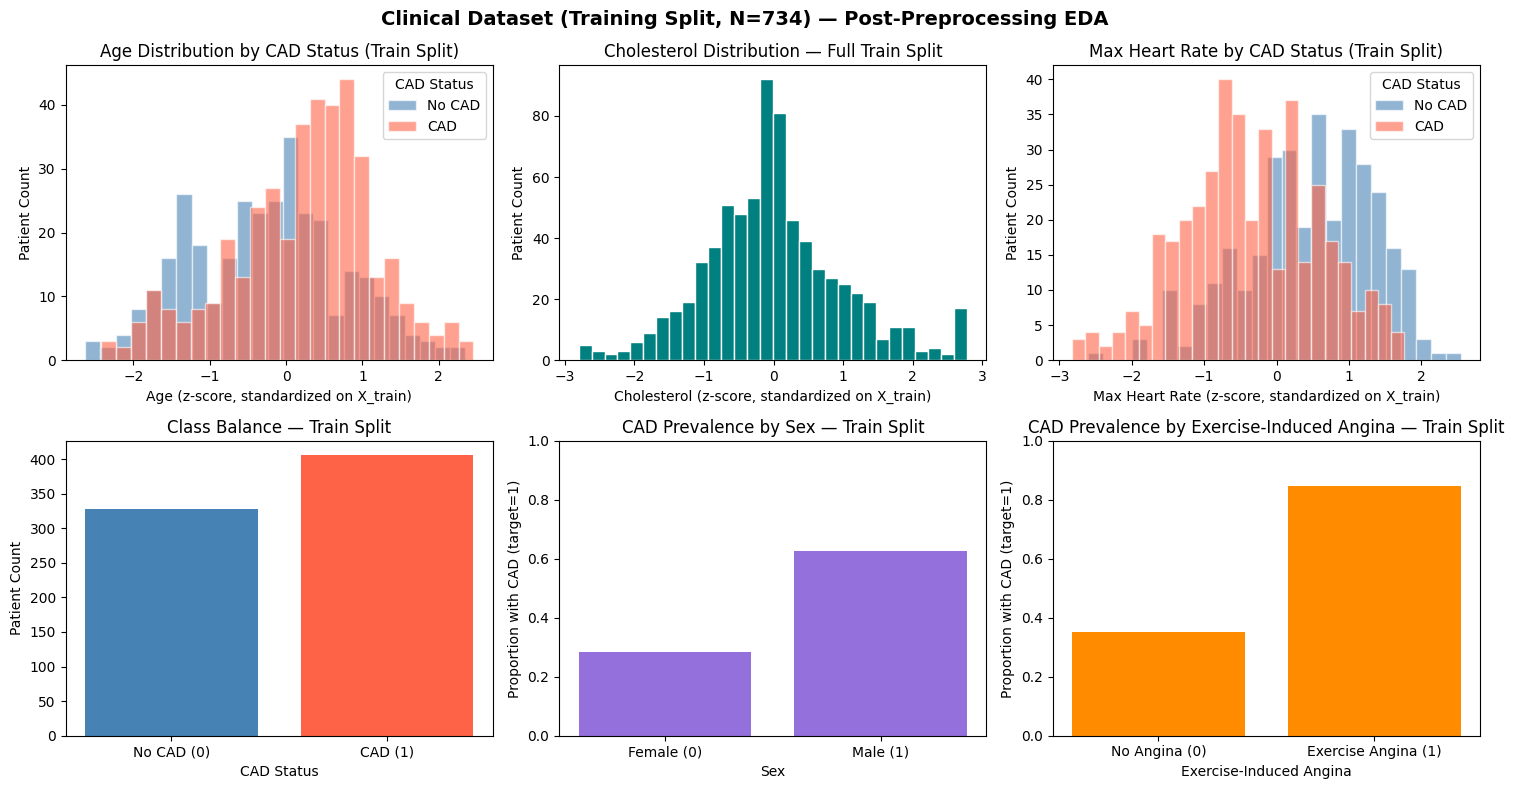


  ✅ EDA plot saved to: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/clinical_eda.png


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Clinical Dataset (Training Split, N=%d) — Post-Preprocessing EDA' % len(df_train_out),
             fontsize=14, fontweight='bold')

# 1. Age distribution by target
for t, label, color in [(0, 'No CAD', 'steelblue'), (1, 'CAD', 'tomato')]:
    subset = df_train_out[df_train_out['target'] == t]['age']
    axes[0,0].hist(subset, bins=25, alpha=0.6, label=label, color=color, edgecolor='white')
axes[0,0].set_title('Age Distribution by CAD Status (Train Split)')
axes[0,0].set_xlabel('Age (z-score, standardized on X_train)')
axes[0,0].set_ylabel('Patient Count')
axes[0,0].legend(title='CAD Status')

# 2. Cholesterol distribution
axes[0,1].hist(df_train_out['cholesterol'], bins=30, color='teal', edgecolor='white')
axes[0,1].set_title('Cholesterol Distribution — Full Train Split')
axes[0,1].set_xlabel('Cholesterol (z-score, standardized on X_train)')
axes[0,1].set_ylabel('Patient Count')

# 3. Max Heart Rate vs target
for t, label, color in [(0, 'No CAD', 'steelblue'), (1, 'CAD', 'tomato')]:
    subset = df_train_out[df_train_out['target'] == t]['max_heart_rate']
    axes[0,2].hist(subset, bins=25, alpha=0.6, label=label, color=color, edgecolor='white')
axes[0,2].set_title('Max Heart Rate by CAD Status (Train Split)')
axes[0,2].set_xlabel('Max Heart Rate (z-score, standardized on X_train)')
axes[0,2].set_ylabel('Patient Count')
axes[0,2].legend(title='CAD Status')

# 4. Target balance
tc = df_train_out['target'].value_counts()
axes[1,0].bar(['No CAD (0)', 'CAD (1)'], [tc.get(0,0), tc.get(1,0)], color=['steelblue','tomato'])
axes[1,0].set_title('Class Balance — Train Split')
axes[1,0].set_xlabel('CAD Status')
axes[1,0].set_ylabel('Patient Count')

# 5. Sex vs target
sex_target = df_train_out.groupby('sex')['target'].mean()
axes[1,1].bar(['Female (0)', 'Male (1)'], [sex_target.get(0,0), sex_target.get(1,0)], color='mediumpurple')
axes[1,1].set_title('CAD Prevalence by Sex — Train Split')
axes[1,1].set_xlabel('Sex')
axes[1,1].set_ylabel('Proportion with CAD (target=1)')
axes[1,1].set_ylim(0, 1)

# 6. Exercise Angina vs target
ea_target = df_train_out.groupby('exercise_angina')['target'].mean()
axes[1,2].bar(['No Angina (0)', 'Exercise Angina (1)'], [ea_target.get(0,0), ea_target.get(1,0)], color='darkorange')
axes[1,2].set_title('CAD Prevalence by Exercise-Induced Angina — Train Split')
axes[1,2].set_xlabel('Exercise-Induced Angina')
axes[1,2].set_ylabel('Proportion with CAD (target=1)')
axes[1,2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(EDA_FIG_PATH, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  ✅ EDA plot saved to: {EDA_FIG_PATH}")


---
## Section 13 — Final Pipeline Validation

This cell runs a comprehensive set of assertions to confirm the pipeline produced correct outputs.

### ⚠️ Why raw test and processed test have different column counts — this is expected

| File | Columns | Reason |
|---|---|---|
| `df_clinical_test_raw.csv` | 12 | Pre-processing snapshot: 11 features + target |
| `df_clinical_test.csv` | 19 | Post-OHE: 18 features + target |

One-hot encoding expands 3 categorical columns into 9 dummies (+7 net new columns).  
The raw file is saved for interpretability and auditing — it is **not** used for model training.

### Checks performed
1. **Row counts** — train + test rows = total dataset rows
2. **Column expansion** — processed test has more columns than raw (OHE confirmed)
3. **NaN check** — no missing values in any processed output
4. **Class balance** — train/test positive rates within 5% of each other
5. **Dtype check** — target is integer, float cols are continuous features
6. **Feature integrity** — `ca` and `thal` are correctly absent
7. **Leakage check** — IQR bounds, imputer, and scaler all fitted on X_train only
8. **Raw train export check** (added 2026-07-22) — `df_clinical_train_raw.csv` shape matches expectations
9. **CV-safe pipeline consistency check** (added 2026-07-22) — Section 11b's `IQRClipper` fences exactly match Section 7b's, hard-asserted rather than eyeballed
10. **Cross-split duplicate leakage check** (added 2026-07-25) — zero patient rows are byte-identical across the train and test raw exports; permanent regression guard for the issue fixed in Section 2a


In [20]:
# ── Section 13 — Final Pipeline Validation ───────────────────────────────────
print("=" * 65)
print("PIPELINE VALIDATION — FINAL CHECKS")
print("=" * 65)

# ── [1] Row count check ───────────────────────────────────────────────────────
print("\n[1] Row count check")
n_train = df_train_out.shape[0]
n_test  = df_test_out.shape[0]
n_total = len(df)
print(f"    df_clinical_train rows    : {n_train}")
print(f"    df_clinical_test rows     : {n_test}")
print(f"    Total dataset rows        : {n_total}")
print(f"    train + test              : {n_train + n_test}")
assert n_train + n_test == n_total, \
    f"Row count mismatch! {n_train} + {n_test} = {n_train+n_test} ≠ {n_total}"
assert df_clinical_test_raw.shape[0] == n_test, \
    f"Raw test row count mismatch: {df_clinical_test_raw.shape[0]} ≠ {n_test}"
print("    ✅ Row counts consistent")

# ── [2] Column expansion check (OHE) ─────────────────────────────────────────
# NOTE: raw test (12 cols) vs processed test (19 cols) is EXPECTED — not a bug.
# One-hot encoding expands chest_pain_type (4 cats), resting_ecg (3 cats),
# st_slope (3 cats) → removes 3 original cols, adds 10 dummies = net +7 cols.
print("\n[2] Column expansion check (One-Hot Encoding)")
raw_cols       = df_clinical_test_raw.shape[1]
processed_cols = df_test_out.shape[1]
print(f"    df_clinical_test_raw cols : {raw_cols}   (pre-OHE: 11 features + target)")
print(f"    df_clinical_test cols     : {processed_cols}  (post-OHE: 18 features + target)")
assert processed_cols > raw_cols, \
    f"Processed test should have MORE columns than raw after OHE, got {processed_cols} vs {raw_cols}"
assert df_train_out.shape[1] == df_test_out.shape[1], \
    f"Train and processed test must have same columns! {df_train_out.shape[1]} ≠ {df_test_out.shape[1]}"
print(f"    Column expansion: {raw_cols} → {processed_cols} (+{processed_cols - raw_cols} from OHE) ✅")
print(f"    Train and test have identical columns ({df_train_out.shape[1]}) ✅")

# ── [3] NaN check ────────────────────────────────────────────────────────────
print("\n[3] NaN check")
train_nans = df_train_out.isnull().sum().sum()
test_nans  = df_test_out.isnull().sum().sum()
print(f"    NaN in df_clinical_train  : {train_nans}")
print(f"    NaN in df_clinical_test   : {test_nans}")
assert train_nans == 0, f"NaN found in train output! ({train_nans})"
assert test_nans  == 0, f"NaN found in test output! ({test_nans})"
print("    ✅ No NaN values in any processed output")

# ── [4] Class balance check ───────────────────────────────────────────────────
print("\n[4] Class balance (stratification check)")
train_pos = df_train_out['target'].mean()
test_pos  = df_test_out['target'].mean()
diff      = abs(train_pos - test_pos)
print(f"    Train positive rate : {train_pos:.4f}  ({df_train_out['target'].sum()} / {n_train})")
print(f"    Test  positive rate : {test_pos:.4f}  ({df_test_out['target'].sum()} / {n_test})")
print(f"    Absolute difference : {diff:.4f}")
assert diff < 0.05, f"Class balance too different: {train_pos:.3f} vs {test_pos:.3f} (diff={diff:.3f})"
print("    ✅ Stratification preserved (rate difference < 5%)")

# ── [5] Dtype check ───────────────────────────────────────────────────────────
print("\n[5] Dtype check")
target_dtype = df_train_out['target'].dtype
print(f"    target dtype (train) : {target_dtype}")
print(f"    target dtype (test)  : {df_test_out['target'].dtype}")
assert str(target_dtype).startswith('int'), \
    f"Target must be integer dtype, got {target_dtype}"
float_feats = [c for c in df_train_out.columns if df_train_out[c].dtype == float and c != 'target']
print(f"    Float feature cols   : {float_feats}")
print(f"    (these are the StandardScaler-transformed continuous features)")
print("    ✅ Dtypes correct")

# ── [6] Feature integrity — ca and thal must be absent ───────────────────────
print("\n[6] Invalid feature check")
for banned in ['ca', 'thal']:
    assert banned not in df_train_out.columns, \
        f"Column '{banned}' must NOT exist — it was intentionally omitted at source!"
    assert banned not in df_test_out.columns, \
        f"Column '{banned}' must NOT exist — it was intentionally omitted at source!"
print("    ✅ 'ca' and 'thal' correctly absent (>90% missing in source — excluded at merge)")

# ── [7] Leakage check ────────────────────────────────────────────────────────
print("\n[7] Leakage check")
# IQR bounds
assert 'iqr_bounds' in dir(), "iqr_bounds not found — was IQR clipping run?"
print(f"    IQR bounds computed from X_train for: {list(iqr_bounds.keys())}")
# Imputer
assert hasattr(imputer, 'n_iter_'), "Imputer not fitted on X_train!"
print(f"    MICE imputer fitted on X_train ({imputer.n_iter_} iterations)")
# Scaler
assert hasattr(scaler, 'mean_'), "Scaler not fitted on X_train!"
print(f"    Scaler fitted on X_train — learned means: {dict(zip(SCALE_COLS, scaler.mean_.round(2)))}")
print("    ✅ No leakage: all fit objects derived from X_train only")

# ── [8] Raw train export check (added 2026-07-22) ────────────────────────────
print("\n[8] Raw train export check")
assert 'df_clinical_train_raw' in dir(), "df_clinical_train_raw not found — was Section 7a run?"
print(f"    df_clinical_train_raw shape : {df_clinical_train_raw.shape}")
assert df_clinical_train_raw.shape[0] == n_train, \
    f"Raw train row count mismatch: {df_clinical_train_raw.shape[0]} ≠ {n_train}"
assert df_clinical_train_raw.shape[1] == df_clinical_test_raw.shape[1], \
    f"Raw train/test column count mismatch: {df_clinical_train_raw.shape[1]} ≠ {df_clinical_test_raw.shape[1]}"
print(f"    Matches df_clinical_test_raw column count ({df_clinical_test_raw.shape[1]}) ✅")
print("    ✅ Raw train export shape correct")

# ── [9] CV-safe pipeline consistency check (added 2026-07-22) ────────────────
print("\n[9] CV-safe pipeline consistency check")
assert 'cv_safe_preprocessor' in dir(), "cv_safe_preprocessor not found — was Section 11b run?"
assert 'iqr_clip' in cv_safe_preprocessor.named_steps, \
    "cv_safe_preprocessor missing expected 'iqr_clip' step"
assert '_sanity_clipper' in dir(), "Section 11b's sanity check did not run"
for col, (lower, upper) in _sanity_clipper.bounds_.items():
    ref_lower, ref_upper = iqr_bounds[col]
    assert np.isclose(lower, ref_lower) and np.isclose(upper, ref_upper), \
        f"CV-safe fence for '{col}' diverges from Section 7b: ({lower:.4f},{upper:.4f}) vs ({ref_lower:.4f},{ref_upper:.4f})"
print(f"    IQRClipper fences match Section 7b for all {len(_sanity_clipper.bounds_)} clipped columns")
print("    ✅ CV-safe pipeline consistent with the fit-once path")

# ── [10] Cross-split duplicate leakage check (added 2026-07-25) ──────────────
print("\n[10] Cross-split duplicate leakage check")
_train_keys = set(map(tuple, df_clinical_train_raw.drop(columns=['target']).fillna('__NA__').values.tolist()))
_test_keys  = set(map(tuple, df_clinical_test_raw.drop(columns=['target']).fillna('__NA__').values.tolist()))
_overlap = _train_keys & _test_keys
print(f"    Train rows (raw, pre-processing) : {len(df_clinical_train_raw)}")
print(f"    Test rows  (raw, pre-processing)  : {len(df_clinical_test_raw)}")
print(f"    Exact-row overlap between splits  : {len(_overlap)}")
assert len(_overlap) == 0, (
    f"LEAKAGE: {len(_overlap)} row(s) are byte-identical across train and test splits! "
    "Section 2a's dedup should make this impossible unless two distinct patients happen to "
    "share identical values on every feature — re-check Section 2a ran before Section 7's split."
)
print("    ✅ No patient record appears in both train and test")

# ── Summary ───────────────────────────────────────────────────────────────────
print()
print("=" * 65)
print("ALL VALIDATION CHECKS PASSED ✅")
print("=" * 65)
print(f"  Outputs written to: {CLINICAL_DIR}")
print()

print(f"  {'File':<40} {'Rows':>6}  {'Cols':>5}  Notes")
print(f"  {'-'*72}")

print(f"  {'df_clinical_train.csv':<40} {df_train_out.shape[0]:>6}  {df_train_out.shape[1]:>5}  scaled + encoded")
print(f"  {'df_clinical_test.csv':<40} {df_test_out.shape[0]:>6}  {df_test_out.shape[1]:>5}  scaled + encoded")
print(f"  {'df_clinical_test_raw.csv':<40} {df_clinical_test_raw.shape[0]:>6}  {df_clinical_test_raw.shape[1]:>5}  pre-processing snapshot")
print(f"  {'df_clinical_train_raw.csv':<40} {df_clinical_train_raw.shape[0]:>6}  {df_clinical_train_raw.shape[1]:>5}  pre-processing snapshot (added 2026-07-22)")
print(f"  {'clinical_imputer.pkl':<40}         MICE (fit on train only)")
print(f"  {'clinical_scaler.pkl':<40}         StandardScaler (fit on train only)")


PIPELINE VALIDATION — FINAL CHECKS

[1] Row count check
    df_clinical_train rows    : 734
    df_clinical_test rows     : 184
    Total dataset rows        : 918
    train + test              : 918
    ✅ Row counts consistent

[2] Column expansion check (One-Hot Encoding)
    df_clinical_test_raw cols : 12   (pre-OHE: 11 features + target)
    df_clinical_test cols     : 19  (post-OHE: 18 features + target)
    Column expansion: 12 → 19 (+7 from OHE) ✅
    Train and test have identical columns (19) ✅

[3] NaN check
    NaN in df_clinical_train  : 0
    NaN in df_clinical_test   : 0
    ✅ No NaN values in any processed output

[4] Class balance (stratification check)
    Train positive rate : 0.5531  (406 / 734)
    Test  positive rate : 0.5543  (102 / 184)
    Absolute difference : 0.0012
    ✅ Stratification preserved (rate difference < 5%)

[5] Dtype check
    target dtype (train) : int64
    target dtype (test)  : int64
    Float feature cols   : ['age', 'sex', 'resting_bp', 'chol

---
# Section 14 — Single-Patient Feature Builder (added 03/08/26)

## What is being done
`build_clinical_features()` replicates this notebook's rename → sentinel-to-NaN → IQR clip → MICE impute → round → one-hot-encode → scale pipeline for a **single new patient**, reusing the actual fitted `imputer`, `scaler`, and now-saved `iqr_bounds` rather than refitting anything (refitting on a single row would be meaningless).

## Why continuous bounds are clipped here, but categorical values are rejected
Section 7b enforces its bounds by **clipping** (capping), not row deletion — that training-time behavior transfers directly to a single new patient: an out-of-fence value gets clipped the same way it would have during training, and is printed so it's visible, not hidden. This is different from NB1's `build_lifestyle_features()`, where training enforced bounds by **deleting** rows — an operation with no single-row equivalent, which is why that function raises an error instead. Categorical fields (`chest_pain_type`, `resting_ecg`, `st_slope`, `sex`, `exercise_angina`, `fasting_blood_sugar`) do raise an error on an unrecognized value — there is no dummy column for a category the model never saw, so no valid row could be produced anyway.

## Reindexing to the deployed model's exact feature order
`target_features` should be `scaler.feature_names_in_.tolist()` pulled from the actual fitted `clinical_pipeline.pkl` (same pattern NB7/NB8/NB1 all use) — not hardcoded here.


In [21]:
# ── Reload the fitted artifacts this function depends on ─────────────────────
with open(IMPUTER_OUT, 'rb') as f:
    _fitted_imputer = pickle.load(f)
with open(SCALER_OUT, 'rb') as f:
    _fitted_scaler = pickle.load(f)
with open(IQR_BOUNDS_OUT, 'rb') as f:
    _fitted_iqr_bounds = pickle.load(f)

_RENAME_MAP = {
    'chest pain type'    : 'chest_pain_type',
    'resting bp s'       : 'resting_bp',
    'fasting blood sugar': 'fasting_blood_sugar',
    'resting ecg'        : 'resting_ecg',
    'max heart rate'     : 'max_heart_rate',
    'exercise angina'    : 'exercise_angina',
    'ST slope'           : 'st_slope',
}
_SENTINEL_COLS  = ['cholesterol', 'resting_bp', 'st_slope']   # 0 → NaN, mirrors Section 5
_CLIP_COLS      = ['cholesterol', 'resting_bp', 'max_heart_rate', 'oldpeak']  # mirrors Section 7b
_ROUND_COLS     = ['cholesterol', 'resting_bp', 'st_slope']   # mirrors Section 8
_OHE_CATEGORIES = {
    'chest_pain_type': [1, 2, 3, 4],
    'resting_ecg'    : [0, 1, 2],
    'st_slope'       : [1, 2, 3],   # 0 is the sentinel-missing value, not a real category
}
_CATEGORICAL_VALID = {
    'sex': [0, 1], 'exercise_angina': [0, 1], 'fasting_blood_sugar': [0, 1],
}

def build_clinical_features(raw: dict, target_features=None) -> pd.DataFrame:
    """
    Build a single-row feature DataFrame for a new patient, matching this notebook's
    training-time transformations exactly — reusing the actual fitted imputer/scaler/
    iqr_bounds, never refitting on a single row.

    Parameters
    ----------
    raw : dict
        Raw patient values using ORIGINAL column names: age, sex, `chest pain type`,
        `resting bp s`, cholesterol, `fasting blood sugar`, `resting ecg`,
        `max heart rate`, `exercise angina`, oldpeak, `ST slope`.
        (0 is a valid, meaningful value for `st_slope`/cholesterol/resting_bp only in
        the sense that it will be treated as missing and imputed — same as training.)
    target_features : list[str], optional
        Exact column order to reindex to — pass
        `clinical_pipeline.calibrated_classifiers_[0].estimator.named_steps['scaler'].feature_names_in_.tolist()`
        from the real fitted pipeline. If None, returns this function's own natural
        column order (only safe for inspection, not for `predict_proba`).

    Raises
    ------
    ValueError
        If a categorical field has a value never seen in training — there's no dummy
        column for it, so no valid row could be produced regardless.
    """
    row = dict(raw)

    # ── Step 1: rename (mirrors Section 4) ────────────────────────────────────────
    for old, new in _RENAME_MAP.items():
        if old in row:
            row[new] = row.pop(old)

    required = ['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol',
                'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate',
                'exercise_angina', 'oldpeak', 'st_slope']
    missing_fields = [f for f in required if f not in row]
    if missing_fields:
        raise ValueError(f'Missing required raw field(s): {missing_fields}')

    # ── Step 2: validate categorical fields (mirrors nothing in training — training
    #    never saw an invalid category because it came from a fixed real dataset;
    #    a new patient's raw input has no such guarantee) ───────────────────────────
    for field, valid in _CATEGORICAL_VALID.items():
        if int(row[field]) not in valid:
            raise ValueError(f'{field}={row[field]!r} not in valid set {valid}')
    for field, valid in _OHE_CATEGORIES.items():
        allowed = valid + ([0] if field == 'st_slope' else [])  # st_slope=0 allowed as sentinel
        if int(row[field]) not in allowed:
            raise ValueError(f'{field}={row[field]!r} not in valid set {allowed}')

    # ── Step 3: sentinel zero → NaN (mirrors Section 5) ───────────────────────────
    for col in _SENTINEL_COLS:
        if row[col] == 0:
            row[col] = np.nan

    # ── Step 4: IQR clip using the SAVED training-derived bounds (mirrors Section 7b) ──
    for col in _CLIP_COLS:
        if pd.isna(row[col]):
            continue   # sentinel-missing — clip happens after imputation instead, below
        lo, hi = _fitted_iqr_bounds[col]
        if not (lo <= row[col] <= hi):
            clipped = min(max(row[col], lo), hi)
            print(f'  ℹ️  {col}={row[col]} clipped to {clipped:.1f} (training fence: [{lo:.1f}, {hi:.1f}])')
            row[col] = clipped

    # ── Step 5: MICE impute using the SAVED fitted imputer (mirrors Section 8) ───────
    # Column order/set must match exactly what the imputer was fit on.
    impute_input_cols = _fitted_imputer.feature_names_in_.tolist()
    row_for_impute = {c: row[c] for c in impute_input_cols}
    df_impute_in = pd.DataFrame([row_for_impute])[impute_input_cols]
    imputed_arr = _fitted_imputer.transform(df_impute_in)
    df_imputed = pd.DataFrame(imputed_arr, columns=impute_input_cols)

    # Re-clip cholesterol/resting_bp/oldpeak/max_heart_rate AFTER imputation too —
    # MICE can produce a value outside the fence even when the input to impute wasn't
    # itself out of range, since it's predicted from other correlated features.
    for col in _CLIP_COLS:
        lo, hi = _fitted_iqr_bounds[col]
        df_imputed[col] = df_imputed[col].clip(lo, hi)

    # ── Step 6: round (mirrors Section 8's post-imputation rounding) ─────────────────
    for col in _ROUND_COLS:
        df_imputed[col] = df_imputed[col].round().astype(int)

    row = df_imputed.iloc[0].to_dict()

    # ── Step 7: one-hot encode (mirrors Section 9) ───────────────────────────────────
    # FIX (found via dry-run test): chest_pain_type/resting_ecg are NEVER rounded back to
    # int after MICE (only cholesterol/resting_bp/st_slope are, per _ROUND_COLS) — they
    # stay float64 all the way to pd.get_dummies(), which is why the real training pipeline
    # produces 'chest_pain_type_1.0' / 'resting_ecg_0.0' (float-style) but 'st_slope_1'
    # (plain int, no '.0') as dummy column names. Casting everything to int here would
    # silently produce the wrong column names for two of the three fields.
    for field, categories in _OHE_CATEGORIES.items():
        raw_val = row.pop(field)
        if field == 'st_slope':
            val = int(raw_val)
            for cat in categories:
                row[f'{field}_{cat}'] = 1 if val == cat else 0
        else:
            val = float(raw_val)
            for cat in categories:
                row[f'{field}_{float(cat)}'] = 1 if val == float(cat) else 0

    df_row = pd.DataFrame([row])

    # ── Step 8: scale using the SAVED fitted scaler (mirrors Section 10) ─────────────
    # NOTE (see header, 03/08/26): NB6's clinical_pipeline applies its OWN second
    # StandardScaler on top of this one — this function only reproduces NB2's half of
    # that chain; the pipeline's internal scaler handles the second pass automatically
    # when you call clinical_pipeline.predict_proba() on this function's output.
    scale_cols = _fitted_scaler.feature_names_in_.tolist()
    df_row[scale_cols] = _fitted_scaler.transform(df_row[scale_cols])

    # ── Step 9: reindex to the deployed model's exact feature order ──────────────────
    if target_features is not None:
        missing_cols = set(target_features) - set(df_row.columns)
        if missing_cols:
            raise ValueError(f'Built row is missing expected feature(s): {missing_cols}')
        df_row = df_row.reindex(columns=target_features)

    return df_row


# ── Self-test with hand-built fake patients (added 03/08/26) ──────────────────────
print('=' * 55)
print('SECTION 14: build_clinical_features() self-test')
print('=' * 55)

_fake_patient = {
    'age': 55, 'sex': 1, 'chest pain type': 3, 'resting bp s': 130, 'cholesterol': 240,
    'fasting blood sugar': 0, 'resting ecg': 0, 'max heart rate': 150,
    'exercise angina': 0, 'oldpeak': 1.2, 'ST slope': 2,
}
_target_feats = X_train.columns.tolist()   # matches this notebook's own final X_train
_result = build_clinical_features(_fake_patient, target_features=_target_feats)
print(f'  ✅ Valid patient → built row with {_result.shape[1]} features, matches X_train column order')

_bad_patient = dict(_fake_patient)
_bad_patient['chest pain type'] = 9   # invalid category — never seen in training
try:
    build_clinical_features(_bad_patient, target_features=_target_feats)
    print('  ⚠️  Expected a ValueError for invalid chest_pain_type but none was raised!')
except ValueError as e:
    print(f'  ✅ Correctly rejected invalid category: {e}')

_clip_patient = dict(_fake_patient)
_clip_patient['cholesterol'] = 700   # far outside training IQR fence — should clip, not error
_result_clip = build_clinical_features(_clip_patient, target_features=_target_feats)
print(f'  ✅ Out-of-fence cholesterol handled by clipping (see ℹ️ message above), not an error')

print('\n[SECTION 14 COMPLETE] ✅')


SECTION 14: build_clinical_features() self-test
  ✅ Valid patient → built row with 18 features, matches X_train column order
  ✅ Correctly rejected invalid category: chest_pain_type=9 not in valid set [1, 2, 3, 4]
  ℹ️  cholesterol=700 clipped to 377.5 (training fence: [109.5, 377.5])
  ✅ Out-of-fence cholesterol handled by clipping (see ℹ️ message above), not an error

[SECTION 14 COMPLETE] ✅
